# 02 — Exploratory Data Analysis

**Pipeline stage:** `Health Indicator -> RUL Prediction` (understanding the data before we
model it)

Notebook 01 built the pipeline; this one uses it to actually *look* at the data — how long
do engines live, which sensors carry degradation signal, how does difficulty scale from
FD001 to FD004, and does a health-indicator-style view of "cycles before failure" reveal a
consistent degradation shape underneath all that per-engine noise?


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from aerorul.data.loader import load_subset
from aerorul.data.schema import SUBSETS, SUBSET_INFO
from aerorul.features.engineering import add_rul_train, select_feature_columns

plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
pd.set_option("display.max_columns", 30)

subsets = {name: load_subset(name) for name in SUBSETS}


## 1. How long do engines live?

Lifetime here means "number of cycles until failure" for train engines (we observe the
whole trajectory) — this is the quantity our models ultimately need to be predicting the
remainder of, at any earlier point in an engine's life.


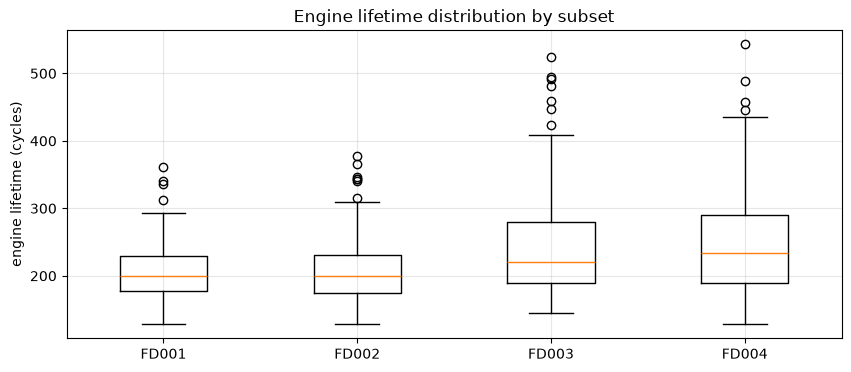

,count,mean,std,min,25%,50%,75%,max
FD001,100.0,206.310000,46.342749,128.0,177.00,199.0,229.25,362.0
FD002,260.0,206.765385,46.782198,128.0,174.00,199.0,230.25,378.0
FD003,100.0,247.200000,86.483840,145.0,189.75,220.5,279.75,525.0
FD004,249.0,245.979920,73.110800,128.0,190.00,234.0,290.00,543.0


In [2]:
lifetimes = {
    name: data.train.groupby("unit_number")["time_cycles"].max()
    for name, data in subsets.items()
}

fig, ax = plt.subplots()
ax.boxplot([lifetimes[s] for s in SUBSETS], tick_labels=SUBSETS)
ax.set_ylabel("engine lifetime (cycles)")
ax.set_title("Engine lifetime distribution by subset")
plt.show()

pd.DataFrame({name: series.describe() for name, series in lifetimes.items()}).T


FD002 and FD004 (six operating conditions) aren't just harder because of the extra
normalization step — their engines also live in a wider, noisier range, and the two-fault-mode
subsets (FD003, FD004) show a wider spread than their one-fault-mode counterparts (FD001,
FD002 respectively). More conditions and more fault modes both add variance a model has to
untangle from actual degradation.


## 2. True RUL distribution in the test set — why the 125-cycle cap matters

Every model in this project is trained against a RUL label capped at 125 cycles (see
notebook 01). Here's what that cap is being compared against at evaluation time: the *true*
RUL from `RUL_*.txt`.


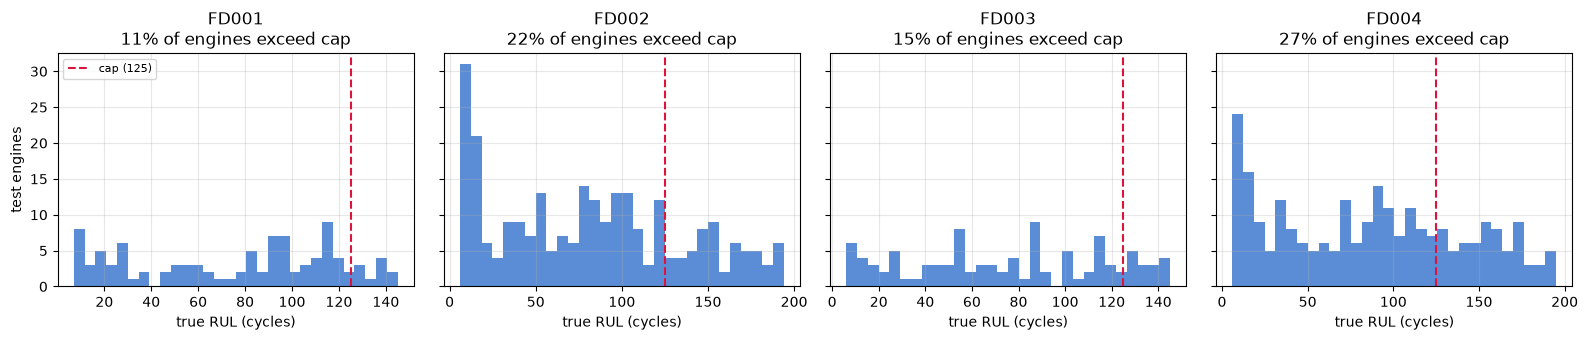

In [3]:
fig, axes = plt.subplots(1, 4, figsize=(16, 3.5), sharey=True)
for ax, name in zip(axes, SUBSETS):
    truth = subsets[name].rul_truth
    over_cap = (truth > 125).mean()
    ax.hist(truth, bins=30, color="#5b8dd6")
    ax.axvline(125, color="crimson", ls="--", label="cap (125)")
    ax.set_title(f"{name}\n{over_cap:.0%} of engines exceed cap")
    ax.set_xlabel("true RUL (cycles)")
axes[0].set_ylabel("test engines")
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.show()


A meaningful fraction of test engines in every subset — especially FD002/FD004 — are
censored well before the cap. A model evaluated *against the cap* on those engines would
never be penalized for being wildly wrong; evaluating against the true value (as
`scripts/compare_models.py` does — see notebook 03) is the only fair comparison.


## 3. Sensor degradation trends

Not every sensor degrades — some are just along for the ride (see the "low-variance" sensors
flagged in notebook 01), and some vary with operating condition rather than wear. Let's plot
a handful of engines on FD001 (single condition, so no normalization confound) and see which
sensors visibly trend toward failure.


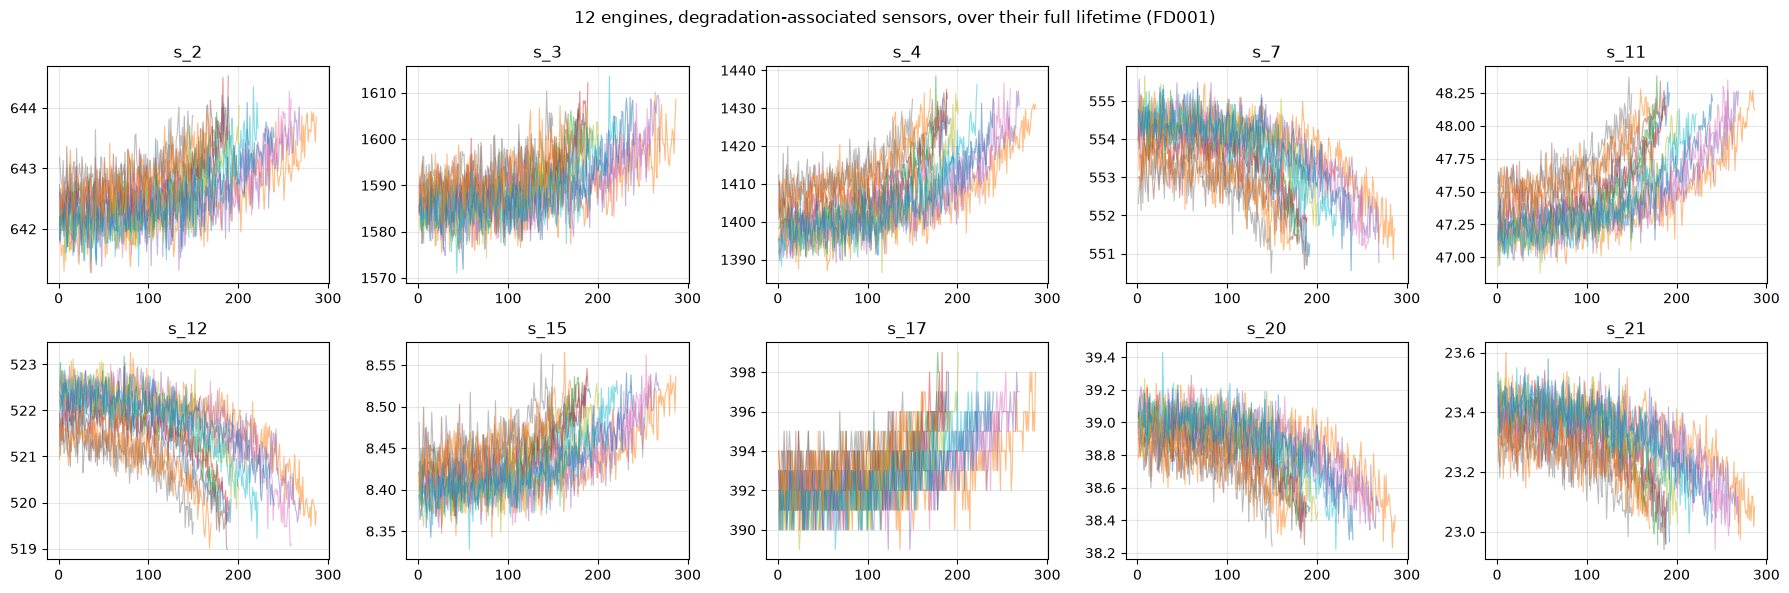

In [4]:
fd001 = subsets["FD001"]
degrading_sensors = ["s_2", "s_3", "s_4", "s_7", "s_11", "s_12", "s_15", "s_17", "s_20", "s_21"]
example_units = fd001.train.unit_number.unique()[:12]

fig, axes = plt.subplots(2, 5, figsize=(18, 6), sharex=False)
for ax, sensor in zip(axes.flat, degrading_sensors):
    for unit in example_units:
        eng = fd001.train[fd001.train.unit_number == unit].sort_values("time_cycles")
        ax.plot(eng.time_cycles, eng[sensor], alpha=0.5, lw=0.8)
    ax.set_title(sensor)
plt.suptitle("12 engines, degradation-associated sensors, over their full lifetime (FD001)")
plt.tight_layout()
plt.show()


Several sensors show a clear monotonic trend across most engines (`s_4`, `s_11`, `s_12`,
`s_7`) — these are exactly the ones the CMAPSS literature flags as HPC/LPT degradation
indicators. Others are noisier or condition-driven and contribute less on their own, which is
why the model relies on the *combination* of all of them rather than any single channel.


## 4. Sensor correlation structure

Many of these 21 channels are physically coupled (e.g. multiple ways of measuring
core/fan speed), so we'd expect substantial redundancy.


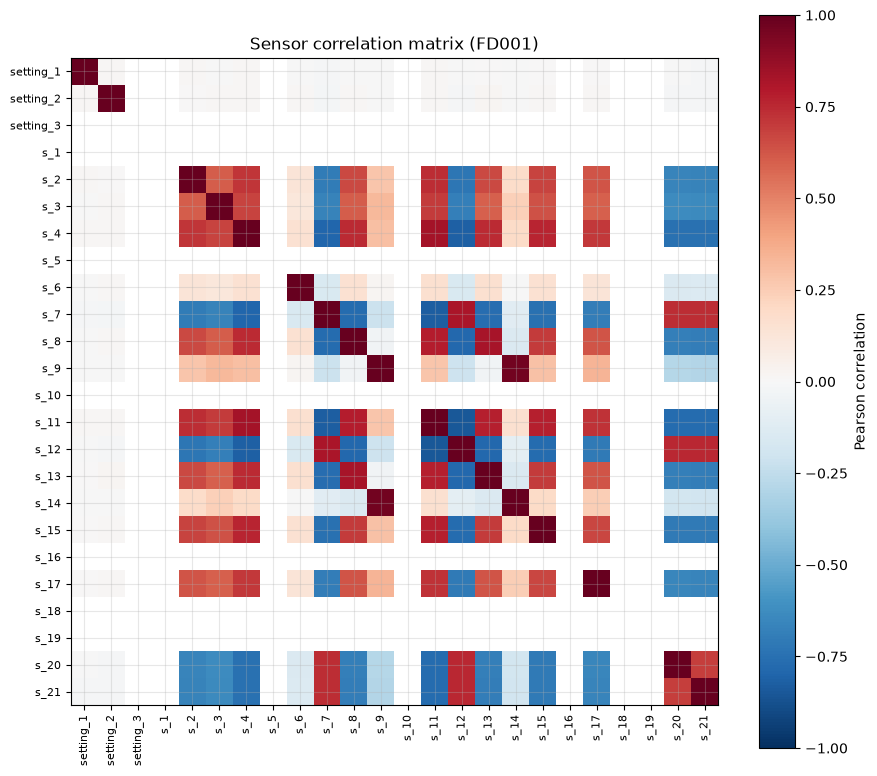

In [5]:
base_cols = select_feature_columns("FD001", drop_low_variance=False)
corr = fd001.train[base_cols].corr()

fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(base_cols)))
ax.set_xticklabels(base_cols, rotation=90, fontsize=8)
ax.set_yticks(range(len(base_cols)))
ax.set_yticklabels(base_cols, fontsize=8)
plt.colorbar(im, label="Pearson correlation")
ax.set_title("Sensor correlation matrix (FD001)")
plt.tight_layout()
plt.show()


Large correlated blocks confirm what the low-variance-sensor list already implied: several
channels move together almost perfectly. This redundancy is exactly why the Weibull AFT
survival model in notebook 04 needs a ridge penalty to fit stably — collinearity makes its
Hessian nearly singular without one.


## 5. Aligning engines by "cycles before failure" — does a common degradation shape emerge?

Plotting sensors against forward cycle count (above) mixes together engines of very different
lifetimes. If we instead align every engine by *cycles remaining until failure* (i.e. flip
the x-axis to count down from 0), a shared degradation shape should emerge from the noise —
this is essentially checking, visually, whether a Health Indicator is a reasonable idea at
all.


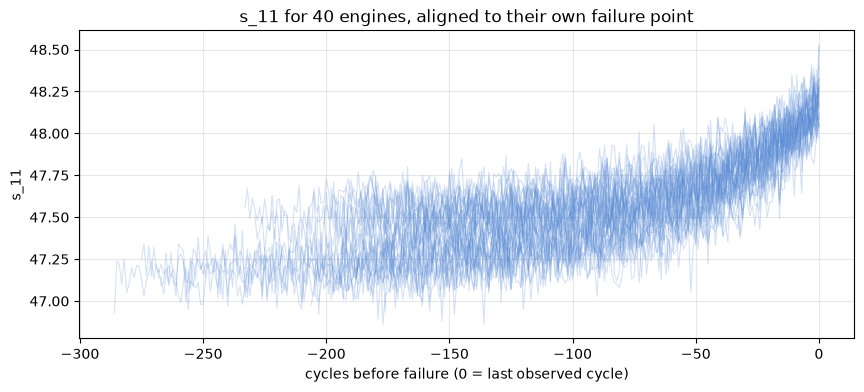

In [6]:
fig, ax = plt.subplots()
sensor = "s_11"
for unit in fd001.train.unit_number.unique()[:40]:
    eng = fd001.train[fd001.train.unit_number == unit].sort_values("time_cycles")
    cycles_before_failure = eng.time_cycles - eng.time_cycles.max()  # 0 at failure, negative before
    ax.plot(cycles_before_failure, eng[sensor], alpha=0.25, lw=0.8, color="#5b8dd6")
ax.set_xlabel("cycles before failure (0 = last observed cycle)")
ax.set_ylabel(sensor)
ax.set_title(f"{sensor} for 40 engines, aligned to their own failure point")
plt.show()


Aligned this way, the last ~40-50 cycles before failure show a much more consistent
divergence across engines than the forward-time view did — exactly the regime the RUL cap
(125 cycles) is designed to focus the model's capacity on.


## Summary

- FD002/FD004 aren't just harder because of extra preprocessing — their engines genuinely
  live over a wider, noisier range, which shows up again in every model's error in
  notebook 03.
- A meaningful fraction of test engines (up to ~20%+ on the multi-condition subsets) have
  true RUL beyond the 125-cycle training cap, which is why evaluation has to use the true
  value, not the capped one (a bug this project actually had and fixed — see the README).
- A handful of sensors (`s_4`, `s_7`, `s_11`, `s_12`) carry most of the visible degradation
  signal; many others are redundant or condition-driven.
- Aligning engines by cycles-before-failure rather than forward cycle count reveals a much
  more consistent degradation shape in the final ~50 cycles of life — validating both the
  RUL cap and the health-indicator concept from notebook 01.

**Next:** `03_modeling.ipynb` trains and compares the five models this project builds:
XGBoost, LSTM, TCN, Transformer, and a Weibull AFT survival model.
